<a href="https://colab.research.google.com/github/HamzaEric/seedlings_classification_CV/blob/main/Notebooks/Preprocessing_%26_data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import os
from pathlib import Path
import torch
import kagglehub
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import shutil
from matplotlib import pyplot as plt
import numpy as np
import collections
from sklearn.model_selection import train_test_split


In [3]:
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('plant-seedlings-classification')

100%|██████████| 1.69G/1.69G [00:27<00:00, 66.8MB/s]

Extracting files...


# **ImageNet Normalization (Mean/Std)**

- Pretrained CNNs not only expect 224×224 input, but also **specific pixel statistics**:  
  - **Mean:** `[0.485, 0.456, 0.406]`  
  - **Standard Deviation:** `[0.229, 0.224, 0.225]`
- These values are computed from the **entire ImageNet dataset** and represent the typical RGB distribution across millions of natural images.

**Why normalize?**
- Ensures input images are **centered** (mean 0) and **scaled** (std ~1).
- Matches the distribution that pretrained weights were optimized on — crucial for transfer learning to work well.
- Without this, the pretrained features would misinterpret brightness/contrast and hurt performance.

In [6]:
!ls /root/.cache/kagglehub/competitions/

plant-seedlings-classification	plant-seedlings-classification.complete


In [9]:
!ls /root/.cache/kagglehub/competitions/plant-seedlings-classification

sample_submission.csv  test  train


In [10]:
!ls /root/.cache/kagglehub/competitions/plant-seedlings-classification/train

 Black-grass	    'Common wheat'	'Scentless Mayweed'
 Charlock	    'Fat Hen'		'Shepherds Purse'
 Cleavers	    'Loose Silky-bent'	'Small-flowered Cranesbill'
'Common Chickweed'   Maize		'Sugar beet'


In [11]:
!ls /root/.cache/kagglehub/competitions/plant-seedlings-classification/test

0021e90e4.png  33748968f.png  65e97117e.png  98d819587.png  cb496f36e.png
003d61042.png  338c7e907.png  664194d19.png  98da6ef4e.png  cb76a7766.png
007b3da8b.png  34dd57ca9.png  6680836dd.png  99036c51d.png  cbba27d89.png
0086a6340.png  3526b05cc.png  668c1007c.png  99569b224.png  cbe761896.png
00c47e980.png  35a90f8d0.png  66ab0e8d0.png  995c7ab1e.png  cc3d2a59a.png
00d090cde.png  35cf9fa01.png  675ec1b0b.png  9a3f20121.png  cc74feadc.png
00ef713a8.png  35ebe165c.png  67ce3eaa6.png  9aa5587fe.png  cd5f0db1c.png
01291174f.png  36839d5e9.png  67e185673.png  9b4800b42.png  cd6adba97.png
026716f9b.png  36d62bf36.png  686dc7ec8.png  9b9911f20.png  ce15eee52.png
02cfeb38d.png  36ed4f215.png  6908fb540.png  9baf94467.png  ce3d280eb.png
03566743d.png  37297a64c.png  6982a9d30.png  9c0c5b731.png  ce42adffb.png
03a2ee656.png  37714071b.png  699d3c707.png  9c32a797e.png  cec5bf198.png
03e322a29.png  377283a21.png  69d1669f8.png  9c777333d.png  cf3a8b2fd.png
03ef36742.png  37c3108d6.png  6a41bf95

In [15]:
data_path = "/root/.cache/kagglehub/competitions/plant-seedlings-classification"
original_test_dir = os.path.join(data_path, "test")
new_parent_dir = os.path.join(data_path, "test_dir")

os.makedirs(new_parent_dir, exist_ok=True)

if os.path.exists(original_test_dir):
    shutil.move(original_test_dir, new_parent_dir)

In [17]:
data_path = "/root/.cache/kagglehub/competitions/plant-seedlings-classification"

test_data_path = os.path.join(data_path, "test_dir")
train_dir = os.path.join(data_path, "train")

# -----------------------------
#  Transformations
# -----------------------------
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# -----------------------------
#  Load datasets
# -----------------------------
train_dataset = datasets.ImageFolder(train_dir, transform=transform)

test_dataset  = datasets.ImageFolder(test_data_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# -----------------------------
#  Verify
# -----------------------------
print(f"Train Classes: {train_dataset.classes}")
print(f"Test Classes found: {test_dataset.classes}")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Test Classes found: ['test']
Train samples: 4750 | Test samples: 794


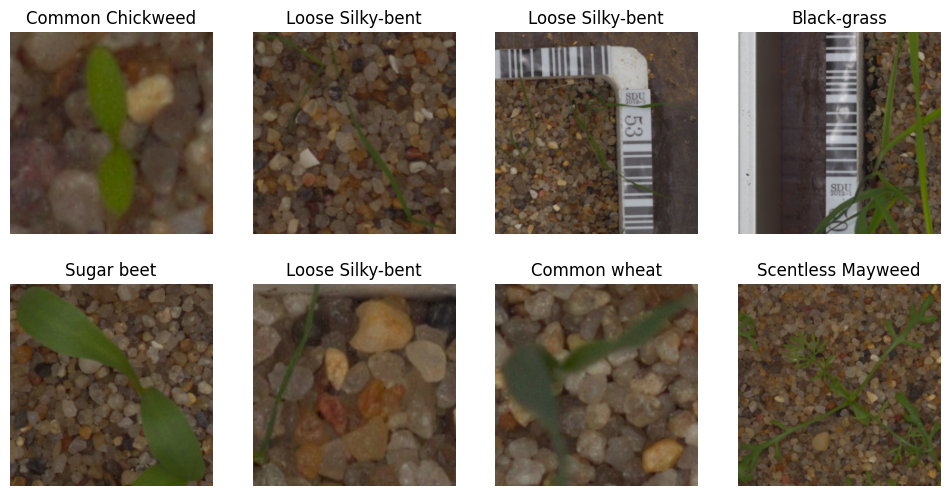

In [19]:
def imshow(inp, title=None):
    """Display a tensor image after unnormalizing (ImageNet stats)."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Show first 8 training images
images, labels = next(iter(train_loader))
fig = plt.figure(figsize=(12, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    imshow(images[i], title=train_dataset.classes[labels[i]])
plt.show()

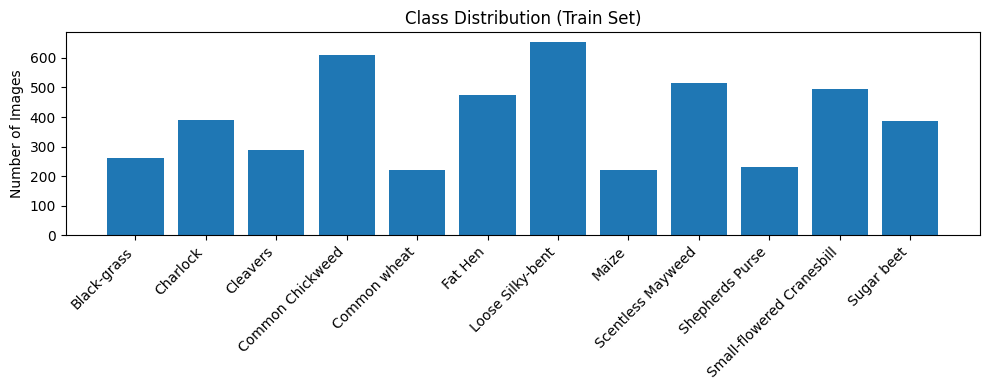

In [21]:
class_counts = collections.Counter([label for _, label in train_dataset.samples])

# Convert to list aligned with class_names
counts = [class_counts[i] for i in range(len(train_dataset.classes))]

# Plot
plt.figure(figsize=(10, 4))
plt.bar(train_dataset.classes, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (Train Set)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [23]:
CT_train_loader_bs20 = DataLoader(train_dataset, batch_size=32, shuffle=True)
CT_test_loader_bs50  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

CT_tr20_images, CT_tr20_labels = next(iter(CT_train_loader_bs20))
CT_te50_images, CT_te50_labels = next(iter(CT_test_loader_bs50))

CT_train_bs20_shape = CT_tr20_images.shape
CT_test_bs50_shape  = CT_te50_images.shape

print("CT_train_bs20_shape:", CT_train_bs20_shape)
print("CT_test_bs50_shape:",  CT_test_bs50_shape)

CT_train_bs20_shape: torch.Size([32, 3, 224, 224])
CT_test_bs50_shape: torch.Size([32, 3, 224, 224])


A **Convolutional Neural Network (CNN)** transforms raw image pixels into class probabilities through a structured hierarchy:

1. **Convolution Layers**  
   - Apply filters (kernels) to detect **local features** (edges, corners).  
2. **Pooling Layers**  
   - Downsample feature maps to reduce spatial size and enforce **translation invariance**.  
3. **Flatten**  
   - Convert 2D feature maps into a 1D vector for dense layers.  
4. **Fully Connected Layers (FC)**  
   - Combine features for **class-level reasoning**.  
5. **Softmax**  
   - Produce probabilities across all classes.

**Baseline CNN (Project 5)**

Here’s a schematic of the **2-conv + 2-FC** model we built for pet breed classification:

```text
Input (3 × 128 × 128)
        │
[Conv2D 3→16, 3×3] → ReLU → MaxPool(2×2)
        │
[Conv2D 16→32, 3×3] → ReLU → MaxPool(2×2)
        │
Flatten (32 × 32 × 32)
        │
[FC: 32×32×32 → 128] → ReLU
        │
[FC: 128 → 37] → Softmax

```


In [25]:
val_dir   = os.path.join(data_path, "val")

os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # All images in this class
    images = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Skip if validation already exists for this class
    val_class_path = os.path.join(val_dir, class_name)
    if not os.path.exists(val_class_path):
        os.makedirs(val_class_path, exist_ok=True)

    # 15% split for validation
    train_imgs, val_imgs = train_test_split(images, test_size=0.15, random_state=42)

    # Move validation images
    for img in val_imgs:
        dest_path = os.path.join(val_class_path, os.path.basename(img))
        shutil.move(img, dest_path)

print(f"Validation split created at: {val_dir}")

Validation split created at: /root/.cache/kagglehub/competitions/plant-seedlings-classification/val


In [27]:
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Paths for train, val, test
test_dir = os.path.join(data_path, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_data_path, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")


Train samples: 4030
Val samples: 720
Test samples: 794
Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
